## **Setup and Data Loading**

In [3]:
import pandas as pd

import re

from string import punctuation

from google.colab import drive

drive.mount("/content/gdrive", force_remount=True)

df = pd.read_csv('/content/gdrive/MyDrive/IMDB Dataset.csv') #Gets data from CSV file located on my Google Drive
df

Mounted at /content/gdrive


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


## **Exploratory Data Analysis (EDA)**

In [4]:
df.isnull()

,review,sentiment
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
49995,False,False
49996,False,False
49997,False,False
49998,False,False


In [5]:
df.isnull().sum()

,0
review,0
sentiment,0


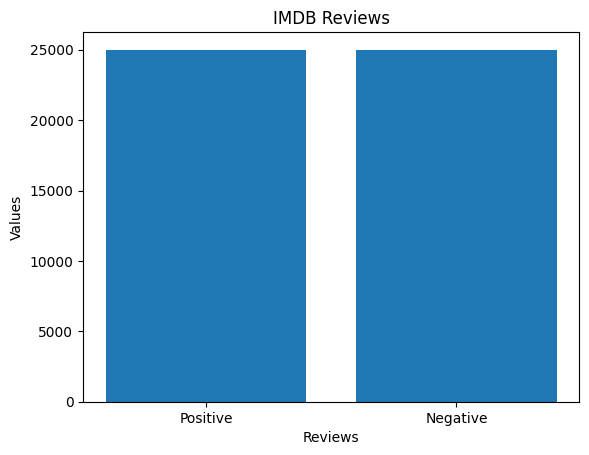

In [6]:
import matplotlib.pyplot as plt

categories = ['Positive', 'Negative']
values = [df[df['sentiment'] == 'positive'].shape[0],
          df[df['sentiment'] == 'negative'].shape[0]]

plt.bar(categories, values)
plt.title('IMDB Reviews')
plt.xlabel('Reviews')
plt.ylabel('Values')
plt.show()



In [7]:
df['lowercase_reviews'] = df['review'].str.lower()  # Convert to lowercase
df

,review,sentiment,lowercase_reviews
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is..."
...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...


In [8]:
df['clean_text'] = df['lowercase_reviews'].str.casefold() # Remove cases (useful for caseless matching) Case folding is a common approach for matching strings
df

,review,sentiment,lowercase_reviews,clean_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is..."
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...


In [9]:
df['removedHyperlinks'] = df['clean_text'].str.replace(r"https?://\S+", "", regex=True) # Remove hyperlinks

df

,review,sentiment,lowercase_reviews,clean_text,removedHyperlinks
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is..."
...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...


In [10]:
df['removedTags'] = df['removedHyperlinks'].str.replace(r"<a[^>]*>(.*?)</a>", r"\1", regex=True) # Remove all HTML tags but keep their contents

df

,review,sentiment,lowercase_reviews,clean_text,removedHyperlinks,removedTags
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is..."
...,...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...


In [11]:
df['removedHTML'] = df['removedTags'].str.replace(r"<.*?>", " ", regex=True) # Remove all HTML tags but keep their contents

df

,review,sentiment,lowercase_reviews,clean_text,removedHyperlinks,removedTags,removedHTML
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. <br /><br />the...,a wonderful little production. the filming t...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is...","petter mattei's ""love in the time of money"" is..."
...,...,...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di...","bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...,i'm going to have to disagree with the previou...


In [12]:
# Initialize an empty list to store strings
text_list = []

# Loop through each row in the DataFrame
for text in df['removedHTML']:
    # Ensure each entry is a string
    text = str(text)

    # Append the cleaned string to the list
    text_list.append(text)

# Print the first 5 entries in the list
print(text_list[0])
print(text_list[1])
print(text_list[2])
print(text_list[3])
print(text_list[4])


one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  i would say the main appeal of the show is due to the fact that it goes where other sho

In [13]:
from textblob import TextBlob #Code Implementation for Sentiment Analysis Using Text Blob

"""
for i in text_list:
  for x in range(0, len(text_list) - 1):
    print(f"Polarity of Text {x} is", TextBlob(text_list[x]).sentiment.polarity)
    print(f"Subjectivity of Text {x} is", TextBlob(text_list[x]).sentiment.subjectivity)

"""

#Determining the Polarity
p_1 = TextBlob(text_list[0]).sentiment.polarity
p_2 = TextBlob(text_list[1]).sentiment.polarity
p_3 = TextBlob(text_list[2]).sentiment.polarity
p_4 = TextBlob(text_list[3]).sentiment.polarity
p_5 = TextBlob(text_list[4]).sentiment.polarity

#Determining the Subjectivity
s_1 = TextBlob(text_list[0]).sentiment.subjectivity
s_2 = TextBlob(text_list[1]).sentiment.subjectivity
s_3 = TextBlob(text_list[2]).sentiment.subjectivity
s_4 = TextBlob(text_list[3]).sentiment.subjectivity
s_5 = TextBlob(text_list[4]).sentiment.subjectivity


print("Polarity of Text 0 is", p_1)
print("Subjectivity of Text 0 is", s_1)
print("\n")

print("Polarity of Text 1 is", p_2)
print("Subjectivity of Text 1 is", s_2)
print("\n")

print("Polarity of Text 2 is", p_3)
print("Subjectivity of Text 2 is", s_3)
print("\n")

print("Polarity of Text 3 is", p_4)
print("Subjectivity of Text 3 is", s_4)
print("\n")

print("Polarity of Text 4 is", p_5)
print("Subjectivity of Text 4 is", s_5)
print("\n")


Polarity of Text 0 is 0.023433179723502305
Subjectivity of Text 0 is 0.4903686635944701


Polarity of Text 1 is 0.1097222222222222
Subjectivity of Text 1 is 0.5593434343434344


Polarity of Text 2 is 0.36095993953136807
Subjectivity of Text 2 is 0.6559334845049131


Polarity of Text 3 is 0.004166666666666664
Subjectivity of Text 3 is 0.4592592592592592


Polarity of Text 4 is 0.21448306595365418
Subjectivity of Text 4 is 0.4513591800356506




In [14]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.4 MB/s eta 0:00:00


In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [16]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer #Using Bag of Words Vectorization-Based Models

sentiment = SentimentIntensityAnalyzer()

sent_0 = sentiment.polarity_scores(text_list[0])
sent_1 = sentiment.polarity_scores(text_list[1])
sent_2 = sentiment.polarity_scores(text_list[2])
sent_3 = sentiment.polarity_scores(text_list[3])
sent_4 = sentiment.polarity_scores(text_list[4])

print("Sentiment of text 0:", sent_0)
print("Sentiment of text 1:", sent_1)
print("Sentiment of text 2:", sent_2)
print("Sentiment of text 3:", sent_3)
print("Sentiment of text 4:", sent_4)


Sentiment of text 0: {'neg': 0.181, 'neu': 0.754, 'pos': 0.065, 'compound': -0.9916}
Sentiment of text 1: {'neg': 0.053, 'neu': 0.765, 'pos': 0.182, 'compound': 0.967}
Sentiment of text 2: {'neg': 0.113, 'neu': 0.665, 'pos': 0.222, 'compound': 0.9745}
Sentiment of text 3: {'neg': 0.127, 'neu': 0.813, 'pos': 0.06, 'compound': -0.9213}
Sentiment of text 4: {'neg': 0.051, 'neu': 0.796, 'pos': 0.153, 'compound': 0.9766}


In [17]:
pip install transformers


In [18]:
import transformers

In [22]:
from transformers import pipeline #Code for Sentiment Analysis Using Transformer based models
sentiment_pipeline = pipeline("sentiment-analysis")
sentiment_pipeline(text_list[0])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


[{'label': 'NEGATIVE', 'score': 0.8250712156295776}]